### **Summary**

This is the most popular disaster event in the history. Titanic the big boat is fall under ocean in 1910 if don't confuse.
So we gonna analyze this eveant to predicting who can survive in this disaster, what sex survive , what type cabin survive or again what type class survive.We gonna answer for all this question to the dataset provide by **kaggle**: https://www.kaggle.com/competitions/titanic/data?select=train.csv the link is there to go take the dataset. So let explain how we gonna attack this problem :

- Take train first because  train have a target
- Exploratory dataset analysis:
  - Checking if have the null or not
  - there we don't check the outliers because the many columns are categoricals so is unecessary to check this
  - Remove all null values
  - Checking again if we have again the null values
- Preprocessing on data we gonna use OneHotEncoder, SimpleImputer and only Standard scaler
-  Train the data : we gonna work with the ensembles models , the boosting, stacking and voting to see what method outperform compare to others
-  Checking the best model by precision because you want to know who survive or not
-  Do ROC_Curve and AUC_Curve to know the model have better performances generally
-  Checking what feature have so much impact to the  target
-  Take test_df
-  apply the same operations to remove the null values
-  Predict the values with X_train
-  Save this in the csv submission

So let's started this big project.

### Exploratory Dataset Analysis

####  Checking a null and remove

In [723]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [725]:
train_df = pd.read_csv("train.csv")

train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [918]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [920]:
print(train_df.isnull().sum().sort_values(ascending=False).head(4))

Cabin          687
PassengerId      0
Survived         0
Pclass           0
dtype: int64


In [922]:
def train_df_clean(df):

    null_values = train_df.isnull().sum()

    if df["Embarked"].isnull().any():
       df["Embarked"].fillna("N", inplace = True)
    else:
        df["Cabin"].fillna("Empty", inplace = True)

    df["Age"].fillna(0,inplace=True)

train_df_clean(train_df)

print(train_df[["Cabin","Age","Embarked"]])

     Cabin   Age Embarked
0    Empty  22.0        S
1      C85  38.0        C
2    Empty  26.0        S
3     C123  35.0        S
4    Empty  35.0        S
..     ...   ...      ...
886  Empty  27.0        S
887    B42  19.0        S
888  Empty   0.0        S
889   C148  26.0        C
890  Empty  32.0        Q

[891 rows x 3 columns]


In [924]:
print(train_df.isnull().sum().sort_values(ascending=False))

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [735]:
train_df["Age"].describe()

count    891.000000
mean      23.799293
std       17.596074
min        0.000000
25%        6.000000
50%       24.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

#### Visualization

In [738]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We gonna make a boxplot to compare Male an female. How many women and men we have in the boat. That's gonna give the idea what sex have the most survived in the boat only with the number. so let's started.

In [846]:
import matplotlib.pyplot as plt
import seaborn as sns

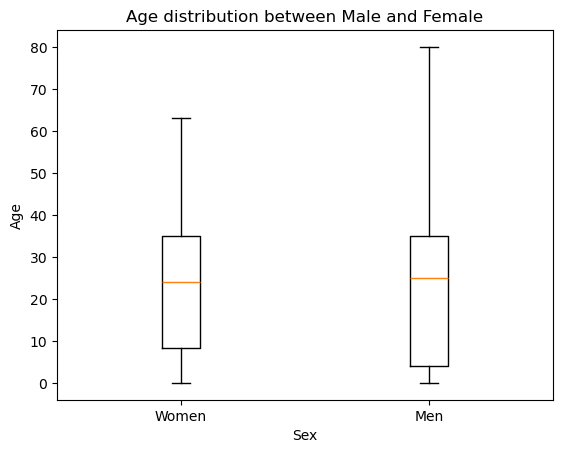

In [743]:
def boxplot_sex(df, title = "Boxplot between Male and female"):

    female_data = df.loc[df["Sex"] == "female","Age"]
    male_data = df.loc[df["Sex"] == "male","Age"]

    plt.boxplot([female_data,male_data],labels=["Women","Men"])
    plt.xlabel("Sex")
    plt.ylabel("Age")
    plt.title(title)

boxplot_sex(train_df,"Age distribution between Male and Female")

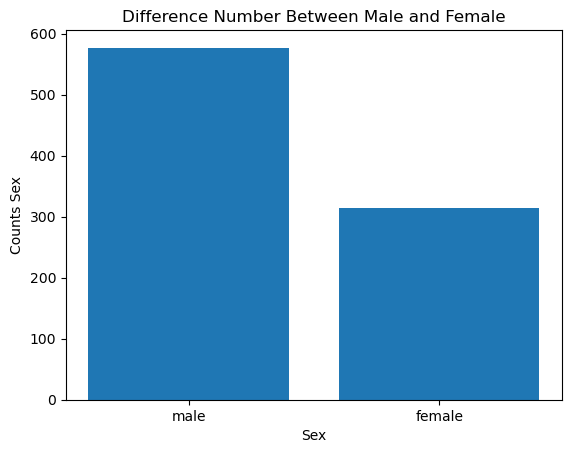

In [745]:
def catplot_sex(df):

    df_count = df["Sex"].value_counts()

    plt.bar(df_count.index ,df_count.values)
    plt.xlabel("Sex")
    plt.ylabel("Counts Sex")
    plt.title("Difference Number Between Male and Female")

catplot_sex(train_df)

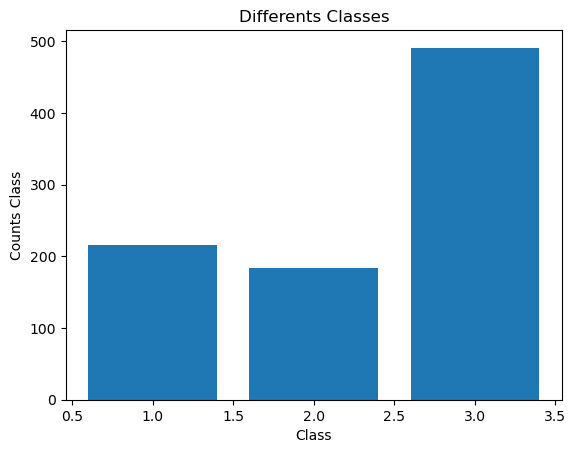

In [747]:
def catplot_sex(df):

    df_count = df["Pclass"].value_counts()

    plt.bar(df_count.index ,df_count.values)
    plt.xlabel("Class")
    plt.ylabel("Counts Class")
    plt.title("Differents Classes")

catplot_sex(train_df)

In [749]:
def survived_class(df):

    df_survived = df[["Pclass","Survived"]]

    group_survived = df_survived.groupby("Pclass")["Survived"].value_counts()

    return group_survived

print(survived_class(train_df))

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


In [751]:
def survived_sex(df):

    df_survived = df[["Sex","Survived"]]

    group_survived = df_survived.groupby("Sex")["Survived"].value_counts()

    return group_survived

print(survived_sex(train_df))



Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


In [753]:
female_data = train_df[train_df["Sex"] == "female"]
male_data   = train_df[train_df["Sex"] == "male"]

female_death_counts = female_data[female_data["Survived"] == 0].shape[0]
male_death_counts   = male_data[male_data["Survived"] == 0].shape[0]

if len(female_data) > 0:
    percentage_female_deaths = female_death_counts / len(female_data) * 100
    print(f"Rate of death woman : {percentage_female_deaths:.2f}%")
else:
    print("No women in the boat.")

if len(male_data) > 0:
    percentage_male_deaths = male_death_counts / len(male_data) * 100
    print(f"Rate of deaths Male: {percentage_male_deaths:.2f}%")
else:
    print("No man in the boat.")

Rate of death woman : 25.80%
Rate of deaths Male: 81.11%


### Features Engineering

In [758]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [760]:
def feature_engineering(df):
    df = df.copy()
    
    if "Name" in df.columns:
        df = df.drop("Name", axis=1)

    cat_col = ["Sex", "Ticket", "Cabin", "Embarked"]
    num_col = ["PassengerId", "Pclass", "Age", "SibSp", "Parch", "Fare"]

    pipeline = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_col),  
        ("num", Pipeline(steps=[
            ("std", StandardScaler()),
            ("minmax", MinMaxScaler())
        ]), num_col)  
    ])

    return pipeline

### Models Training

In [970]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve,classification_report
from xgboost import XGBClassifier
from scipy.interpolate import interp1d
from catboost import CatBoostClassifier
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [972]:
X = train_df.drop(columns={"Survived","Name"},axis=1)
y = train_df["Survived"]

pipeline = feature_engineering(X)
# Transform X_test and X_train
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.01,random_state=1)

X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

#Features Names
features = pipeline.get_feature_names_out()

# Dataframe for the X_test and X_train transformed
X_train_transformed = pd.DataFrame(X_train_transformed,columns=features)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=features)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100,verbose=0,n_jobs=2),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42,learning_rate=0.9,verbose=0,n_estimators=100),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=6,use_label_encoder=False, eval_metric='auc'),
    "CatBoost": CatBoostClassifier(random_state=42, iterations=100, learning_rate=0.9, depth=6, verbose=0)
}


In [950]:
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    
    print(15*"*", f"{name}", 15*"*")
    print(classification_report(y_test, y_pred))
    print()

*************** Logistic Regression ***************
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9


*************** Decision Tree ***************
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9


*************** Random Forest ***************
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                        

In [951]:
FOLDS = 20
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# This will store the final results
auc_scores = {}
fold_roc_curves = {}  

for name, model in models.items():
    # oof_preds will hold the out-of-fold predicted probability for each row in y
    oof_preds = np.zeros(len(y))  
    
    # For averaging the ROC curve, define a "common" FPR grid
    # on which we'll interpolate each fold's TPR.
    mean_fpr = np.linspace(0, 1, 100)
    tprs_per_fold = []  # store each fold's interpolated TPR
    
    # We do the cross-validation loop
    for train_idx, val_idx in skf.split(X, y):
        # 1) Split for this fold
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # 2) Build a new pipeline for this fold
        pipeline_fold = feature_engineering(X_train_fold)
        
        # 3) Fit-transform train fold, transform val fold
        X_train_transformed = pipeline_fold.fit_transform(X_train_fold)
        X_val_transformed = pipeline_fold.transform(X_val_fold)
        
        # 4) Train the model
        model.fit(X_train_transformed, y_train_fold)
        
        # 5) Predict probabilities on val fold
        if hasattr(model, "predict_proba"):
            y_val_proba = model.predict_proba(X_val_transformed)[:, 1]
        else:
            y_val_proba = model.decision_function(X_val_transformed)
        
        # 6) Store OOF predictions
        oof_preds[val_idx] = y_val_proba
        
        # 7) Compute ROC for this fold
        fpr_fold, tpr_fold, _ = roc_curve(y_val_fold, y_val_proba)
        
        # 8) Interpolate TPR at mean_fpr points (so we can average across folds)
        #    We'll use scipy's interp1d or np.interp
        interp_func = interp1d(fpr_fold, tpr_fold, kind="linear", bounds_error=False, fill_value="extrapolate")
        tpr_interpolated = interp_func(mean_fpr)
        # Make sure it starts at 0 and ends at 1 (common convention)
        tpr_interpolated[0] = 0.0
        tpr_interpolated[-1] = 1.0
        
        tprs_per_fold.append(tpr_interpolated)
    
    # After all folds, compute the OOF AUC
    fold_auc = roc_auc_score(y, oof_preds)
    auc_scores[name] = fold_auc
    
    # Average the TPR across folds to get a "mean ROC curve"
    mean_tpr = np.mean(tprs_per_fold, axis=0)
    # Standard practice: ensure it starts at 0 and ends at 1
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0
    
    fold_roc_curves[name] = (mean_fpr, mean_tpr)
    
    print(f"{name} |AUC = {fold_auc:.4f}")

Logistic Regression |AUC = 0.8674
Decision Tree |AUC = 0.7950
Random Forest |AUC = 0.8707
Gradient Boosting |AUC = 0.8681
Support Vector Machine |AUC = 0.8698
XGBoost |AUC = 0.8638
CatBoost |AUC = 0.8608


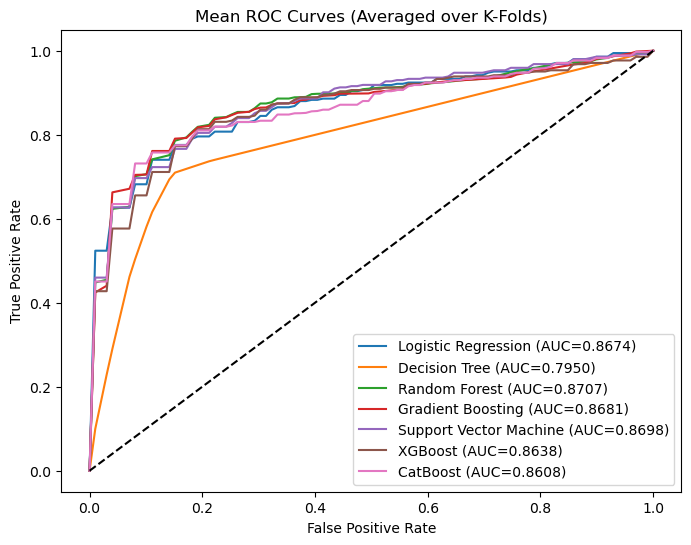

In [952]:
# Example: Plot each model's mean ROC curve
plt.figure(figsize=(8,6))
for name, (mean_fpr, mean_tpr) in fold_roc_curves.items():
    plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC={auc_scores[name]:.4f})")

plt.plot([0,1],[0,1],"k--")
plt.title("Mean ROC Curves (Averaged over K-Folds)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### Features Importances

In [954]:
best_model_name = max(auc_scores,key= auc_scores.get)
best_model = models[best_model_name]
print(f" Best Model is : {best_model_name} with the AUC equal : {auc_scores[best_model_name]:.4f} 👑")

 Best Model is : Random Forest with the AUC equal : 0.8707 👑


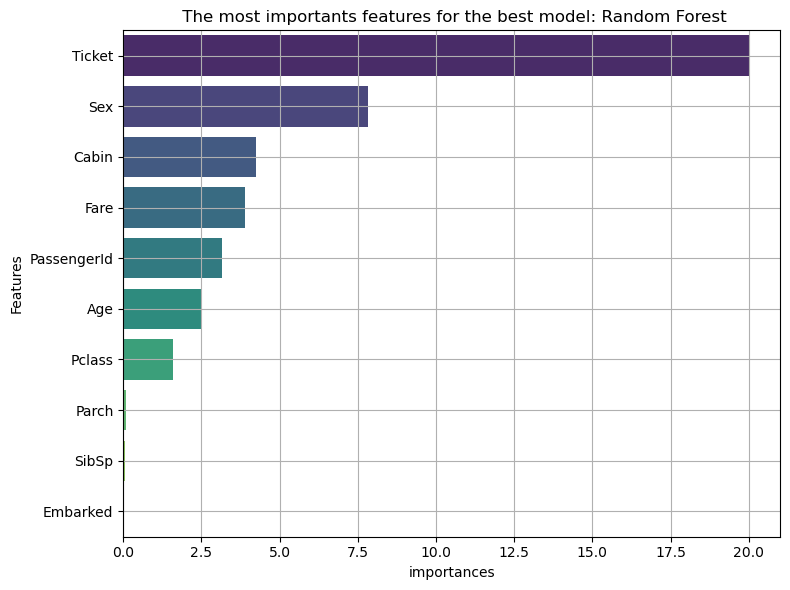

In [955]:
X_encoded= pd.get_dummies(X,drop_first=True)
model = RandomForestClassifier(random_state=42, n_estimators=100,verbose=0,n_jobs=2)
model.fit(X_encoded,y)

# Take features names and importances in the model
feature_names = X_encoded.columns
importances = model.feature_importances_

features = pd.DataFrame({"Features" : feature_names,"Importances":importances})

def get_original_col(feature_name):
    return feature_name.split("_")[0]

features["OriginalColumn"] = features["Features"].apply(get_original_col)

df_grouped = features.groupby("OriginalColumn")["Importances"].sum().reset_index()
df_grouped.sort_values("Importances", ascending=False, inplace=True)

#print(df_grouped)

scaler = MinMaxScaler(feature_range=(0, 20))
df_grouped["ScaledImportance"] = scaler.fit_transform(df_grouped[["Importances"]])

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_grouped,
    x="ScaledImportance",
    y="OriginalColumn",
    palette="viridis"
)
plt.xlabel("importances")
plt.ylabel("Features")
plt.title(f" The most importants features for the best model: {best_model_name}")
plt.grid(True)
plt.tight_layout()
plt.show()

### Decisions Boundaries (3D)

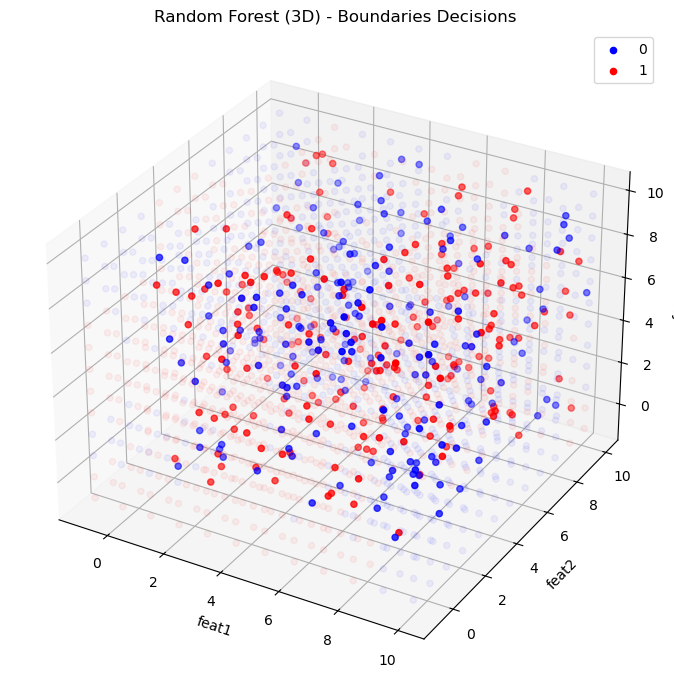

In [957]:
np.random.seed(42)
n_samples = 400

# Create a 3 features and one random y binary
X_arr = np.random.rand(n_samples, 3) * 10
y_arr = np.random.randint(0, 2, size=n_samples)

# DataFrame (3 columns), Series for y
X_3d = pd.DataFrame(X_arr, columns=["feat1", "feat2", "feat3"])
y = pd.Series(y_arr, name="target")


X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)

# Create a meshgrid
x_min, x_max = X_3d["feat1"].min() - 1, X_3d["feat1"].max() + 1
y_min, y_max = X_3d["feat2"].min() - 1, X_3d["feat2"].max() + 1
z_min, z_max = X_3d["feat3"].min() - 1, X_3d["feat3"].max() + 1

# step need to be big otherwise is gonna blow memory
step = 1.0
xx, yy, zz = np.meshgrid(
    np.arange(x_min, x_max, step),
    np.arange(y_min, y_max, step),
    np.arange(z_min, z_max, step)
)


grid_points = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])

#Predictions of grid
preds = model.predict(grid_points)

# Display in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


X_3d_np = X_3d.to_numpy()    
y_np = y.to_numpy()          

mask0 = (y_np == 0)
mask1 = (y_np == 1)

ax.scatter(
    X_3d_np[mask0, 0],
    X_3d_np[mask0, 1],
    X_3d_np[mask0, 2],
    c='blue', label='0'
)
ax.scatter(
    X_3d_np[mask1, 0],
    X_3d_np[mask1, 1],
    X_3d_np[mask1, 2],
    c='red', label='1'
)


grid_class0 = grid_points[preds == 0]
grid_class1 = grid_points[preds == 1]

ax.scatter(
    grid_class0[:, 0],
    grid_class0[:, 1],
    grid_class0[:, 2],
    c='blue', alpha=0.05
)
ax.scatter(
    grid_class1[:, 0],
    grid_class1[:, 1],
    grid_class1[:, 2],
    c='red', alpha=0.05
)

ax.set_xlabel("feat1")
ax.set_ylabel("feat2")
ax.set_zlabel("feat3")
ax.set_title(f"{best_model_name} (3D) - Boundaries Decisions")
ax.legend()
plt.tight_layout()
plt.show()


### Test_df

In [960]:
test_df = pd.read_csv("test.csv",sep=",")

test_df

print(test_df.isnull().sum().sort_values(ascending=False).head())

Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
dtype: int64


In [961]:
def test_df_clean(df):

    null_values = train_df.isnull().sum()

    if df["Fare"].isnull().any():
       df["Fare"].fillna("0", inplace = True)
    else:
        df["Cabin"].fillna("Empty", inplace = True)

    df["Age"].fillna(0,inplace=True)

    if "Name" in df.columns:
        df.drop("Name",axis=1)

test_df_clean(test_df)

print(test_df[["Cabin","Age","Fare"]])

    Cabin   Age     Fare
0     NaN  34.5   7.8292
1     NaN  47.0      7.0
2     NaN  62.0   9.6875
3     NaN  27.0   8.6625
4     NaN  22.0  12.2875
..    ...   ...      ...
413   NaN   0.0     8.05
414  C105  39.0    108.9
415   NaN  38.5     7.25
416   NaN   0.0     8.05
417   NaN   0.0  22.3583

[418 rows x 3 columns]


In [974]:
X_test_df = test_df.drop(columns=["Name"])  
X_test_df_transformed = pipeline.transform(X_test_df)

X_test_df_transformed = pd.DataFrame(X_test_df_transformed, columns=features)

rf = RandomForestClassifier(random_state=42, n_estimators=100,verbose=0,n_jobs=5)
rf.fit(X_train_transformed,y_train)
 
y_pred_test = rf.predict(X_test_df_transformed)

In [976]:
titanic_df= pd.DataFrame({"PassengerId":test_df["PassengerId"],"Survived":y_pred_test})

print(titanic_df.head())

titanic_df.to_csv("submission.csv", index=False)

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


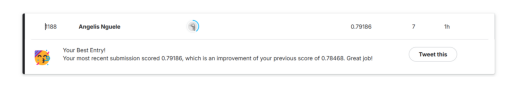

In [909]:
image = plt.imread("C:/Users/angel/OneDrive/Pictures/Screenshots/Screenshot 2025-03-16 002316.png") 

plt.imshow(image)
plt.axis("off")  
plt.show()